In [3]:
import pandas as pd
import numpy as np
import sympy as sp
from scipy.stats import norm
from scipy.optimize import root_scalar

In [203]:
import numpy as np
import math

def theta_norm_from_grid(t_grid, sigma_grid, B_grid, *, eps=1e-12):
    """
    Compute ||Theta|| over a grid:
      sqrt( ∫ || sigma^{-1}(t) B(t) ||^2 dt )
    using trapezoids.

    sigma_grid: scalar array, vector array (diag), or matrix array.
    """
    t = np.asarray(t_grid, dtype=float)
    if t.ndim != 1 or len(t) < 2 or not np.all(np.diff(t) > 0):
        raise ValueError("t_grid must be 1D, strictly increasing, length >= 2.")

    s = np.asarray(sigma_grid, dtype=float)
    b = np.asarray(B_grid, dtype=float)

    # scalar sigma, scalar B
    if s.ndim == 1 and b.ndim == 1:
        if np.any(np.abs(s) < eps):
            raise ZeroDivisionError("sigma too close to 0 on grid.")
        vals = (b / s) ** 2

    # diagonal sigma vectors: shapes (n, d)
    elif s.ndim == 2 and b.ndim == 2:
        if s.shape != b.shape:
            raise ValueError("sigma_grid and B_grid must match shape for diagonal case.")
        if np.any(np.abs(s) < eps):
            raise ZeroDivisionError("Some diagonal entries sigma too close to 0.")
        x = b / s
        vals = np.sum(x * x, axis=1)

    # full matrices: sigma (n, d, d), B (n, d)
    elif s.ndim == 3 and b.ndim == 2:
        n, d, d2 = s.shape
        if d != d2 or b.shape != (n, d):
            raise ValueError("Expected sigma_grid (n,d,d) and B_grid (n,d).")
        vals = np.empty(n)
        for i in range(n):
            x = np.linalg.solve(s[i], b[i])
            vals[i] = x @ x

    else:
        raise ValueError("Unsupported shapes for sigma_grid / B_grid.")

    return math.sqrt(float(np.trapz(vals, t)))

# For constant rate r
def inthelog(T, C = 0.7, r = 0.05):
    """MATLAB: 0.3./exp(0.05*t)"""
    # return (1-C) * np.exp(-r * T)
    return (1-C) / np.exp(r * T)

In [ ]:
import math
from scipy.stats import norm

def G_VaR(x: float, y: float, alpha: float) -> float:
    # x - 1/2 y + N^{-1}(alpha) * sqrt(y)
    if y < 0:
        raise ValueError("y must be >= 0")
    return x - 0.5 * y + norm.ppf(alpha) * math.sqrt(y)

def G_AVaR(x: float, y: float, alpha: float) -> float:
    # x + ln( N( N^{-1}(alpha) - sqrt(y) ) )
    if y < 0:
        raise ValueError("y must be >= 0")
    inside = norm.cdf(norm.ppf(alpha) - math.sqrt(y))
    inside = max(inside, 1e-300)  # avoid log(0) in extreme tails
    return x + math.log(inside)

def G_LEL(x: float, y: float, alpha: float) -> float:
    # N( N^{-1}(alpha) - sqrt(y) )
    if y < 0:
        raise ValueError("y must be >= 0")
    return norm.cdf(norm.ppf(alpha) - math.sqrt(y))

# Epsilon* solvers

In [290]:
from scipy.stats import norm
from scipy.optimize import brentq
import math


def solve_epsilon(theta_norm_T: float, alpha: float, A: float) -> float:
    """
    h(eps) = eps*theta_norm_T - ln(A) - 0.5*eps^2 + norm.ppf(alpha)*eps
    """
    z = float(norm.ppf(alpha))
    b = float(theta_norm_T) + z
    disc = b * b - 2.0 * math.log(A)
    return b + math.sqrt(disc)   # maximum root


def solve_epsilon_avar_lel(theta_norm_T: float, alpha: float, A: float, lel: bool = False,
                            *, x0=0, step=1.0, max_expand=200000,
                            bracket_min=-1e6, bracket_max=1e6,
                            xtol=1e-6, rtol=1e-6, maxiter=20000) -> float:

    if not (0.0 < alpha < 1.0):
        raise ValueError("alpha must be in (0,1).")
    if A <= 0.0:
        raise ValueError("A must be > 0 for ln(A).")
    theta = float(theta_norm_T)
    z = float(norm.ppf(alpha))
    # lnA = math.log(A)

    # use logcdf for stability: log(Phi(.))
    if lel:
        def h(eps:float) -> float:
            return norm.ppf(alpha) - norm.ppf(A) - eps
    else:
        def h(eps: float) -> float:
            return eps * theta - math.log(A) + norm.logcdf(z - eps)

    # bracket search around x0
    a = max(bracket_min, x0 - step)
    b = min(bracket_max, x0 + step)
    fa = h(a)
    fb = h(b)

    k = 0
    while fa * fb > 0 and k < max_expand:
        step *= 2.0
        a = max(bracket_min, x0 - step)
        b = min(bracket_max, x0 + step)
        fa = h(a)
        fb = h(b)
        k += 1

    if fa * fb > 0:
        raise ValueError(
            "Could not find a sign-changing bracket for h(eps)=0. "
            "Try a different x0/step, or check parameters (A, alpha, theta)."
        )

    return brentq(h, a, b, xtol=xtol, rtol=rtol, maxiter=maxiter)

# Optimal strategies

In [297]:
def opt_strategy(eps_star: float, theta_norm_T: float, Cov, B_df: pd.DataFrame):
    """
    Computes row-wise (eps_star / ||Theta||_T) * Cov^{-1} * B(t_i)
    for B_df shaped (n,d). Cov is constant (d,d).

    Returns: (n,d) ndarray
    """
    if theta_norm_T == 0:
        raise ZeroDivisionError("theta_norm_T is 0; cannot divide by ||Theta||_T.")

    B = B_df.to_numpy(dtype=float)   # (n,d)
    C = np.asarray(Cov, dtype=float) # (d,d)

    n, d = B.shape
    if C.shape != (d, d):
        raise ValueError(f"Cov must have shape {(d,d)}, got {C.shape}.")

    # Solve Cov X = B^T  => X = Cov^{-1} B^T  (X is d x n)
    X = np.linalg.solve(C, B.T).T    # (n,d)

    out = (eps_star / theta_norm_T) * X
    return pd.DataFrame(out, index=B_df.index, columns=B_df.columns)

In [41]:
import numpy as np

def B_t(b, r):
    """
    Compute B(t) = b(t) - r(t) when b and r are callables (or constants).

    b, r can be:
      - callables: b(t), r(t)
      - numbers (treated as constants)
    """
    # b_val = b(t) if callable(b) else float(b)
    # r_val = r(t) if callable(r) else float(r)
    return b - r


def B_from_paths(b_grid, r_grid):
    """
    Compute B(t_i) = b(t_i) - r(t_i) for arrays sampled on the same time grid.
    Returns an array of same shape.
    """
    b_grid = np.asarray(b_grid, dtype=float)
    r_grid = np.asarray(r_grid, dtype=float)
    if b_grid.shape != r_grid.shape:
        raise ValueError("b_grid and r_grid must have the same shape.")
    return b_grid - r_grid

In [204]:
u = [0.08, 0.1, 0.12]
beta = 0.015
betas = [0.75 * beta, 0.5 * beta, 0.25 * beta]
phi = 0.75
r = 0.05
alpha = 0.05

T = 8.0
# x = np.linspace(0.0, T, 1000)

def time_grid_df(time, n=1000, col="t"):
    t = np.linspace(0.0, float(time), int(n))
    return pd.DataFrame({col: t})

x = time_grid_df(T, n=10000)

vt = np.array([[0.2, 0.0, 0.0],
                   [0.0, 0.25, 0.0],
                   [0.0, 0.0, 0.3]], dtype=float)

    # Interpreting the intended MATLAB correlation matrix:
rhot = np.array([[1.0,  -0.6,  -0.8],
                     [-0.6,  1.0,  0.5],
                     [-0.8, 0.5,  1.0]], dtype=float)

leftside = np.linalg.inv(vt) @ np.linalg.inv(rhot) @ np.linalg.inv(vt)

def b_stock(u_, b_, phi_, t):
    return u_ + b_*np.cos(phi_ * t)

In [307]:
b_1 = b_stock(u[0], betas[0], phi, x)
b_2 = b_stock(u[1], betas[1], phi, x)
b_3 = b_stock(u[2], betas[2], phi, x)

b = b_1
b["b_2"] = b_2
b["b_3"] = b_3
b.columns.values[0] = "b_1"

B = B_t(b, r)

cov_target = vt @ rhot @ vt
theta = theta_norm_from_df(B, x, cov_target)
A = inthelog(T = 8)
epsilon_stern = solve_epsilon(theta, alpha = 0.01, A = A)
optimal_strategies_for_min_risk = opt_strategy(epsilon_stern, theta, cov_target, B)
epsilon_stern_avar = solve_epsilon_avar_lel(theta, alpha = alpha, A=A * alpha)
optimal_strategies_for_min_risk_avar = opt_strategy(epsilon_stern_avar, theta, cov_target, B)
epsilon_stern_lel = solve_epsilon_avar_lel(theta, alpha = alpha, A=A * alpha, lel = True)
optimal_strategies_for_min_risk_lel = opt_strategy(epsilon_stern_lel, theta, cov_target, B)

In [318]:
def prep_r_col(df):
    df["r_w"] = 1 -  df["b_1"] - df["b_2"] - df["b_3"]
    return df

def split_3dfs_into_4dfs_var_avar_lel(df_var: pd.DataFrame,
                                      df_avar: pd.DataFrame,
                                      df_lel: pd.DataFrame,
                                      *,
                                      col_names=("var", "avar", "lel")):
    if any(d.shape[1] < 4 for d in (df_var, df_avar, df_lel)):
        raise ValueError("Each input DataFrame must have at least 4 columns.")
    if not (df_var.index.equals(df_avar.index) and df_var.index.equals(df_lel.index)):
        raise ValueError("Input DataFrames must have the same index (same rows/order).")

    def make_k(k: int) -> pd.DataFrame:
        out = pd.concat(
            [
                df_var.iloc[:, k].rename(col_names[0]),
                df_avar.iloc[:, k].rename(col_names[1]),
                df_lel.iloc[:, k].rename(col_names[2]),
            ],
            axis=1,
        )
        return out

    return make_k(0), make_k(1), make_k(2), make_k(3)

In [300]:
# for the min risk for given expected wealth
M = 5
X0 = 1
chi = math.log(M / (X0 * np.exp(r * T)))
optimal_strategies_for_min_risk_given_M = opt_strategy(chi, theta, cov_target, B)

In [308]:
optimal_strategies_for_min_risk = prep_r_col(optimal_strategies_for_min_risk)
optimal_strategies_for_min_risk_avar = prep_r_col(optimal_strategies_for_min_risk_avar)
optimal_strategies_for_min_risk_lel = prep_r_col(optimal_strategies_for_min_risk_lel)
optimal_strategies_for_min_risk_given_M = prep_r_col(optimal_strategies_for_min_risk_given_M)

In [319]:
ak1, ak2, ak3, rfr = split_3dfs_into_4dfs_var_avar_lel(optimal_strategies_for_min_risk,
                                optimal_strategies_for_min_risk_avar, optimal_strategies_for_min_risk_lel)

# plottings

In [330]:
def plot_strat(df: pd.DataFrame, T: float = 8.0, *, xlabel="t", ylabel="portfolio weights", title=None):
    """
    Creates an evenly spaced grid t in [0, T] with n = len(df) points,
    then plots every column of df against that grid.

    Returns (fig, ax, grid_df) where grid_df has the generated grid.
    """
    n = len(df)
    if n < 2:
        raise ValueError("df must have at least 2 rows to generate a grid.")

    t = np.linspace(0.0, float(T), n)

    fig, ax = plt.subplots(figsize=(10, 5))
    for col in df.columns:
        ax.plot(t, df[col].to_numpy(dtype=float), label=str(col))

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title or "Optimal strategy invested")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()

    grid_df = pd.DataFrame({"t": t}, index=df.index)
    # return fig, ax, grid_df

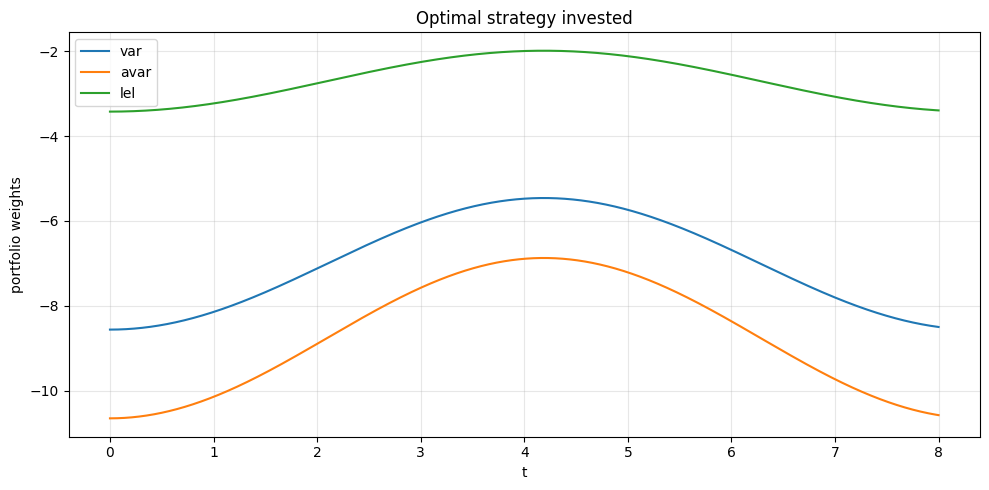

In [332]:
plot_strat(rfr)

In [248]:
def h1(eps: float, z, A) -> float:
        return eps * theta + norm.logcdf(z - eps) - math.log(A)

def h2(eps: float, alpha, A) -> float:
        return norm.ppf(alpha) - norm.ppf(alpha * A) - eps

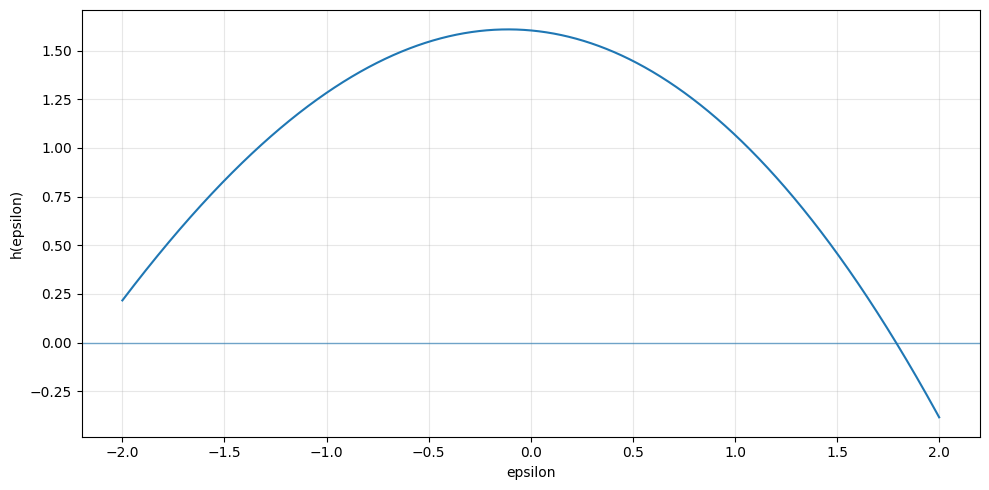

In [258]:
import matplotlib.pyplot as plt
eps = np.linspace(-2, 2, 10000)

z = norm.ppf(alpha)
h = eps * theta - math.log(A * alpha) + norm.logcdf(z - eps)
# h = z - norm.ppf(alpha * A) - eps
# h = norm.cdf(z - eps)
# h = eps * theta + norm.logcdf(z - eps)

plt.figure(figsize=(10, 5))
plt.plot(eps, h)
plt.axhline(0.0, linewidth=1.0, alpha=0.6)
plt.xlabel("epsilon")
plt.ylabel("h(epsilon)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
epy = np.linspace(-2, 2, 50)
z = float(norm.ppf(alpha))
for t in epy:
    ht = h1(eps = t, z = z, A = A * alpha)
    print(t, "max h(t):", np.nanmax(ht), "  count f(t)>0:", (ht > 0).sum().sum())

-2.0 max h(t): 0.21633141474784878   count f(t)>0: 1
-1.9183673469387754 max h(t): 0.3272187036437515   count f(t)>0: 1
-1.836734693877551 max h(t): 0.43428963731011105   count f(t)>0: 1
-1.7551020408163265 max h(t): 0.5374113686745376   count f(t)>0: 1
-1.6734693877551021 max h(t): 0.636455960922671   count f(t)>0: 1
-1.5918367346938775 max h(t): 0.7313004994029537   count f(t)>0: 1
-1.510204081632653 max h(t): 0.8218271497722145   count f(t)>0: 1
-1.4285714285714286 max h(t): 0.9079231687172133   count f(t)>0: 1
-1.3469387755102042 max h(t): 0.9894808735349128   count f(t)>0: 1
-1.2653061224489797 max h(t): 1.0663975766406013   count f(t)>0: 1
-1.183673469387755 max h(t): 1.1385754907394139   count f(t)>0: 1
-1.1020408163265307 max h(t): 1.2059216099801375   count f(t)>0: 1
-1.0204081632653061 max h(t): 1.2683475719418609   count f(t)>0: 1
-0.9387755102040818 max h(t): 1.3257695048101583   count f(t)>0: 1
-0.8571428571428572 max h(t): 1.37810786360087   count f(t)>0: 1
-0.77551020408

In [ ]:
sigma = sigma_from_v_rho(vt, rhot)
# cov_target = np.diag(vt) @ rhot @ np.diag(vt)
cov_target = vt @ rhot @ vt

print(np.allclose(sigma @ sigma.T, cov_target))

In [56]:
def sigma_from_v_rho(v, rho):
    """
    Build sigma such that sigma @ sigma.T = V @ rho @ V,
    with V = diag(v) if v is a vector, or V=v if v is already a matrix.

    Parameters
    ----------
    v : (d,) array-like or (d,d) array-like
        Vols (vector) or diagonal vol matrix V.
    rho : (d,d) array-like
        Correlation matrix (must be symmetric positive definite for Cholesky).

    Returns
    -------
    sigma : (d,d) np.ndarray
    """
    rho = np.asarray(rho, dtype=float)
    if rho.ndim != 2 or rho.shape[0] != rho.shape[1]:
        raise ValueError("rho must be a square (d,d) matrix.")

    v_arr = np.asarray(v, dtype=float)
    if v_arr.ndim == 1:
        V = np.diag(v_arr)
    elif v_arr.ndim == 2:
        V = v_arr
    else:
        raise ValueError("v must be a vector (d,) or matrix (d,d).")

    # Cholesky factor rho = L L^T (requires SPD)
    L = np.linalg.cholesky(rho)
    sigma = V @ L
    return sigma